# Data Preparation

The Walmart dataset does not require extensive modifications.
The main adjustments consist of adding flags to capture anomalous or structural changes as the store level. Although more advanced techniques may be applied in later stages, the initial approach relies on classical time series models, which handle part of the required preparation internally.

## Data Parsing
The `Date` column is stored as an object data type, and is converted to a more appropriate `datetime` format.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

walmart_ds = pd.read_csv("../data/raw/walmart.csv")
walmart_ds["Date"] = pd.to_datetime(
    walmart_ds["Date"],
    format="%d-%m-%Y"
)
walmart_ds = walmart_ds.sort_values(by="Date", ascending=True)
walmart_ds["Date"].info()

<class 'pandas.core.series.Series'>
Index: 6435 entries, 0 to 6434
Series name: Date
Non-Null Count  Dtype         
--------------  -----         
6435 non-null   datetime64[ns]
dtypes: datetime64[ns](1)
memory usage: 100.5 KB


## Feature Engineering
### Anomalous Values

Anomaly_Flag
0    6434
1       1
Name: count, dtype: int64


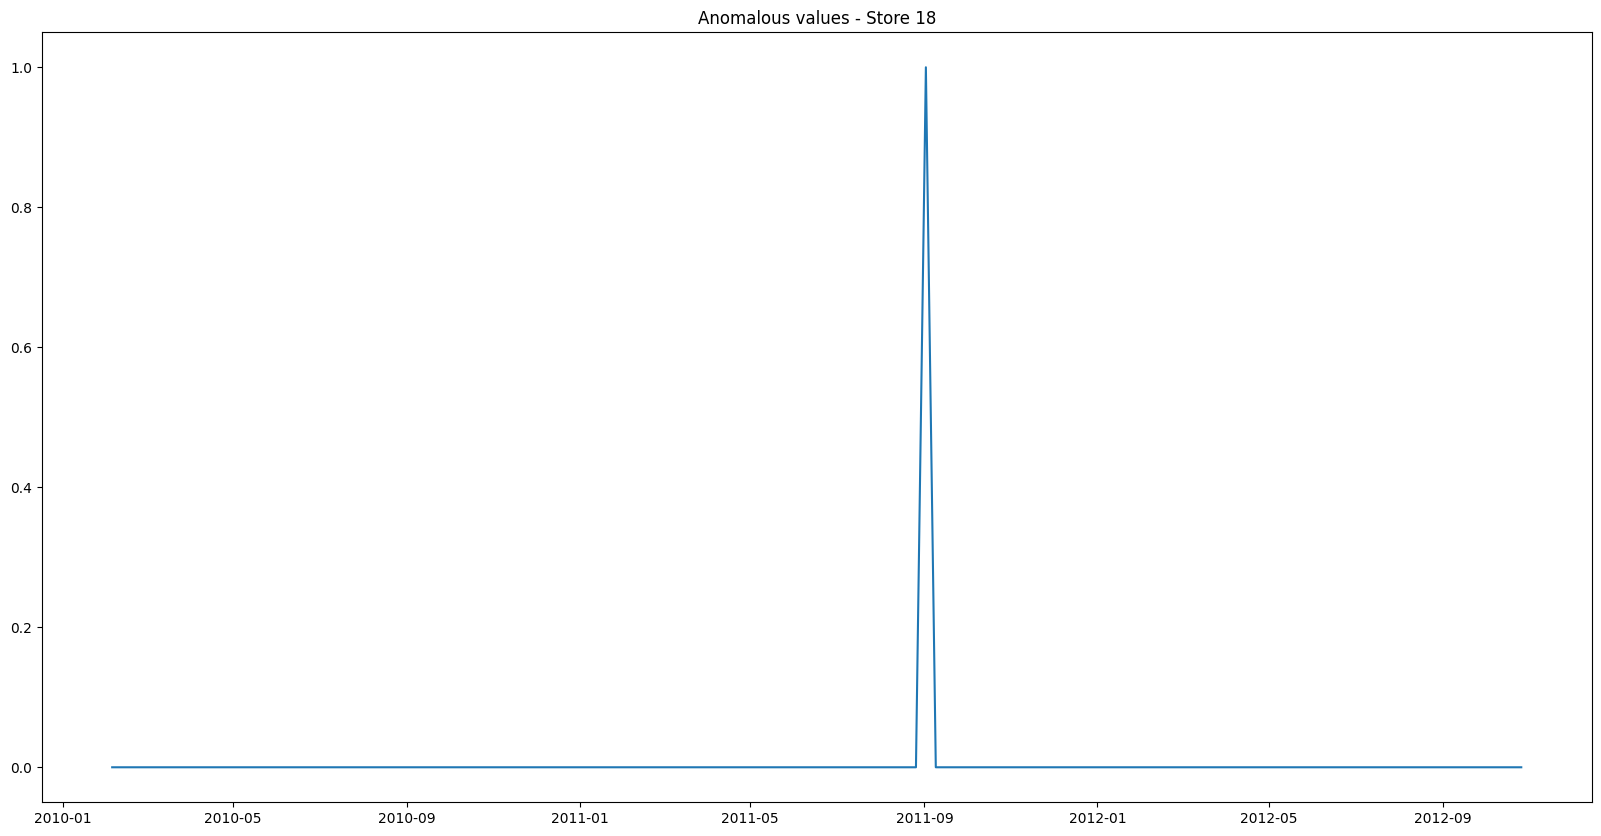

In [2]:
walmart_ds["Anomaly_Flag"] = 0
walmart_ds.loc[(walmart_ds["Store"]==18) & (walmart_ds["Date"] == pd.to_datetime("2011-09-02")), "Anomaly_Flag"] = 1
print(walmart_ds["Anomaly_Flag"].value_counts())
plt.figure(figsize=(20,10))
plt.plot(walmart_ds[walmart_ds["Store"]==18]["Date"], walmart_ds[walmart_ds["Store"]==18]["Anomaly_Flag"])
plt.title("Anomalous values - Store 18")
plt.show();

An anomalous values flag is added as the `Anomaly_Flag` column,
set to `False` by default. 

A `True` value is assigned for Store 18
to indicate detected anomalous behavior.

### Structural Change Flag

Structural_Change_Flag
0    6335
1     100
Name: count, dtype: int64


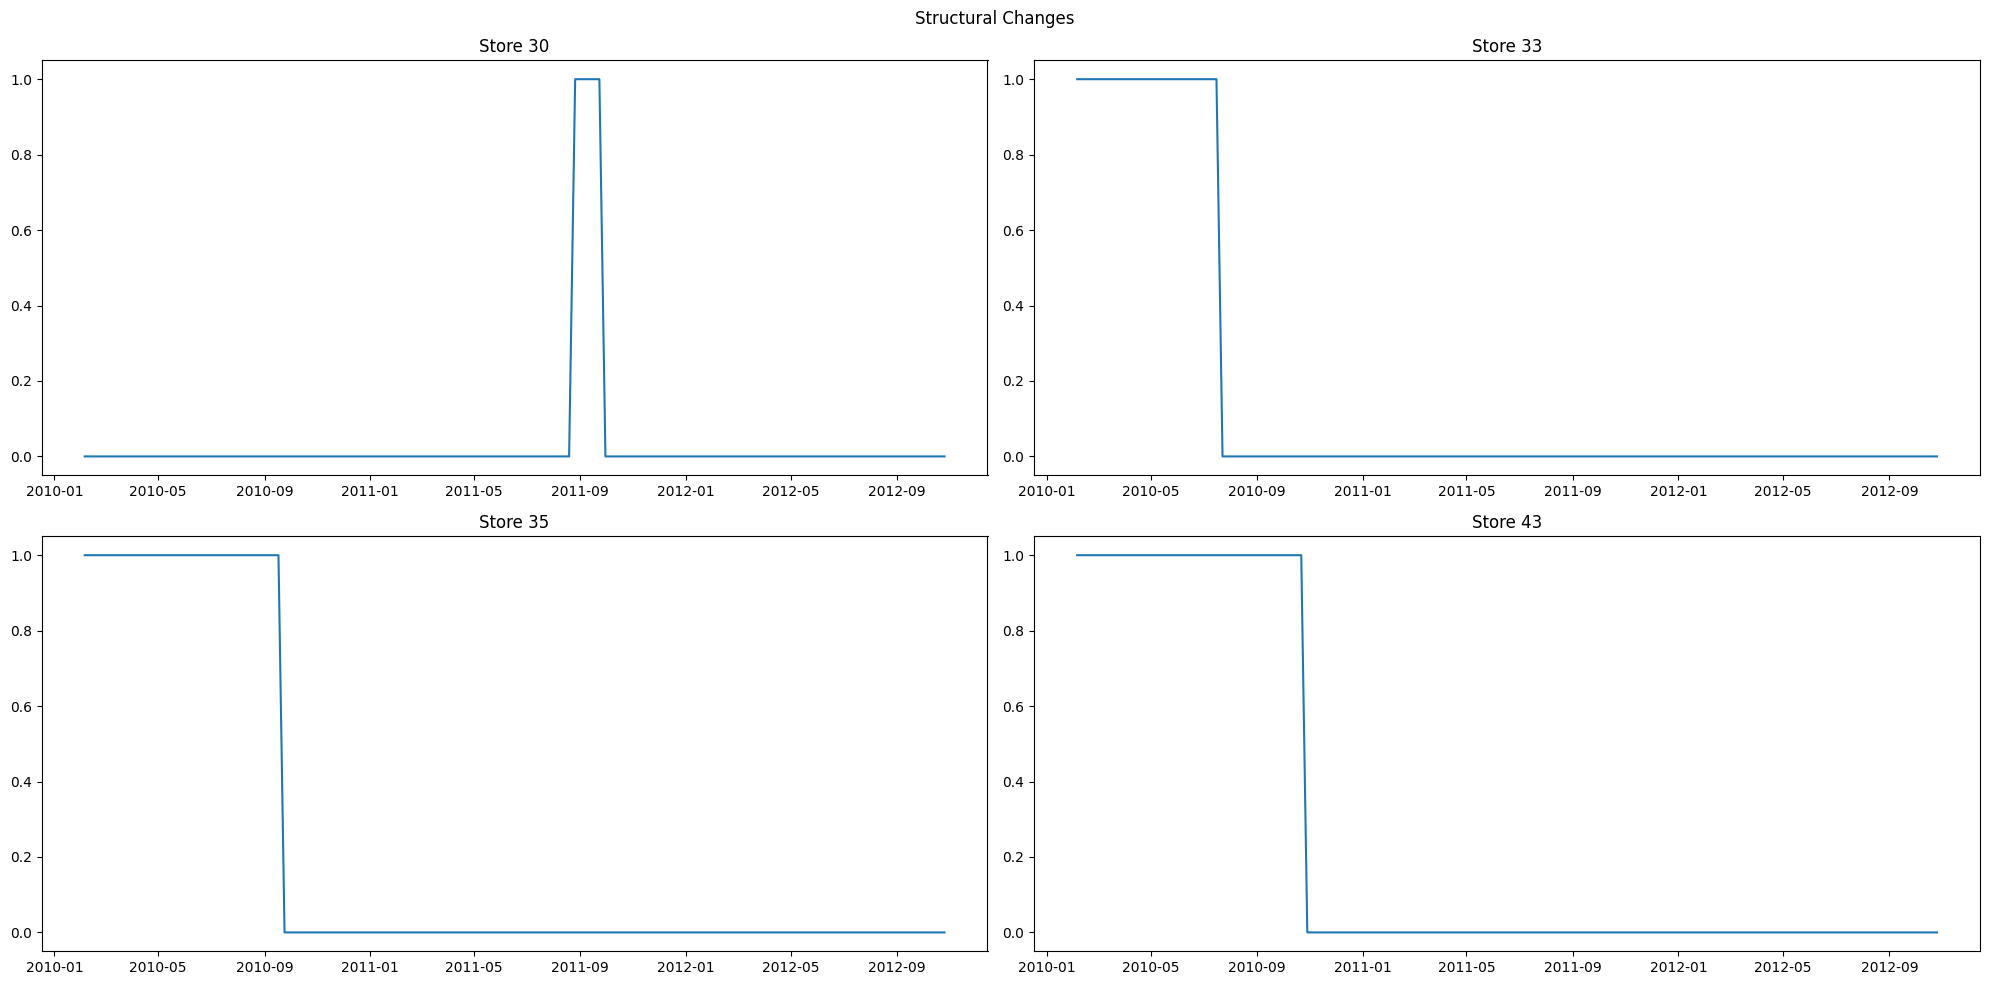

In [3]:
walmart_ds["Structural_Change_Flag"] = 0
walmart_ds.loc[(walmart_ds["Store"]==30) & walmart_ds["Date"].between(pd.to_datetime("2011-08-25"), pd.to_datetime("2011-09-29")), "Structural_Change_Flag"] = 1
walmart_ds.loc[(walmart_ds["Store"]==33) & walmart_ds["Date"].between(pd.to_datetime("2010-02-05"), pd.to_datetime("2010-07-20")), "Structural_Change_Flag"] = 1
walmart_ds.loc[(walmart_ds["Store"]==35) & walmart_ds["Date"].between(pd.to_datetime("2010-02-05"), pd.to_datetime("2010-09-20")), "Structural_Change_Flag"] = 1
walmart_ds.loc[(walmart_ds["Store"]==43) & walmart_ds["Date"].between(pd.to_datetime("2010-02-05"), pd.to_datetime("2010-10-25")), "Structural_Change_Flag"] = 1
print(walmart_ds["Structural_Change_Flag"].value_counts())

fig, ((ax0, ax1), (ax2, ax3)) = plt.subplots(nrows=2, ncols=2, figsize=(20, 10))
ax0.plot(walmart_ds[walmart_ds["Store"]==30]["Date"], walmart_ds[walmart_ds["Store"]==30]["Structural_Change_Flag"])
ax0.set_title("Store 30")
ax1.plot(walmart_ds[walmart_ds["Store"]==33]["Date"], walmart_ds[walmart_ds["Store"]==33]["Structural_Change_Flag"])
ax1.set_title("Store 33")
ax2.plot(walmart_ds[walmart_ds["Store"]==35]["Date"], walmart_ds[walmart_ds["Store"]==35]["Structural_Change_Flag"])
ax2.set_title("Store 35")
ax3.plot(walmart_ds[walmart_ds["Store"]==43]["Date"], walmart_ds[walmart_ds["Store"]==43]["Structural_Change_Flag"])
ax3.set_title("Store 43")
fig.suptitle("Structural Changes")
fig.tight_layout();

Structural changes values flag is added as the `Structural_Change_Flag` column,
set to `False` by default. 

`True` values are assigned for Store 30, 33, 35 and 43
to indicate detected structural changes behavior.